In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import re

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
log_path = "../dataset/BGL.log"

with open(log_path, "r", encoding="utf-8", errors="ignore") as f:
    logs = f.readlines()

print(f"Total Log Count: {len(logs):,}")

Total Log Count: 4,747,963


In [3]:
for i in range(5):
    print(logs[i])

- 1117838570 2005.06.03 R02-M1-N0-C:J12-U11 2005-06-03-15.42.50.363779 R02-M1-N0-C:J12-U11 RAS KERNEL INFO instruction cache parity error corrected

- 1117838570 2005.06.03 R02-M1-N0-C:J12-U11 2005-06-03-15.42.50.527847 R02-M1-N0-C:J12-U11 RAS KERNEL INFO instruction cache parity error corrected

- 1117838570 2005.06.03 R02-M1-N0-C:J12-U11 2005-06-03-15.42.50.675872 R02-M1-N0-C:J12-U11 RAS KERNEL INFO instruction cache parity error corrected

- 1117838570 2005.06.03 R02-M1-N0-C:J12-U11 2005-06-03-15.42.50.823719 R02-M1-N0-C:J12-U11 RAS KERNEL INFO instruction cache parity error corrected

- 1117838570 2005.06.03 R02-M1-N0-C:J12-U11 2005-06-03-15.42.50.982731 R02-M1-N0-C:J12-U11 RAS KERNEL INFO instruction cache parity error corrected



In [4]:
parsed_logs = []

for line in logs:

    parts = line.strip().split()

    if len(parts) < 9:
        continue

    parsed_logs.append({
        "Label": parts[0],
        "Timestamp": parts[1],
        "Date": parts[2],
        "Node": parts[3],
        "Time": parts[4],
        "NodeRepeat": parts[5],
        "Type": parts[6],
        "Component": parts[7],
        "Severity": parts[8],
        "Message": " ".join(parts[9:])
    })

df = pd.DataFrame(parsed_logs)

df.head()

,Label,Timestamp,Date,Node,Time,NodeRepeat,Type,Component,Severity,Message
0,-,1117838570,2005.06.03,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.363779,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected
1,-,1117838570,2005.06.03,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.527847,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected
2,-,1117838570,2005.06.03,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.675872,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected
3,-,1117838570,2005.06.03,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.823719,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected
4,-,1117838570,2005.06.03,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.982731,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected


In [5]:
print(df.shape)

(4747963, 10)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4747963 entries, 0 to 4747962
Data columns (total 10 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   Label       object
 1   Timestamp   object
 2   Date        object
 3   Node        object
 4   Time        object
 5   NodeRepeat  object
 6   Type        object
 7   Component   object
 8   Severity    object
 9   Message     object
dtypes: object(10)
memory usage: 362.2+ MB


In [7]:
df.describe(include="all")

,Label,Timestamp,Date,Node,Time,NodeRepeat,Type,Component,Severity,Message
count,4747963,4747963,4747963,4747963,4747963,4747963,4747963,4747963,4747963,4747963
unique,42,299849,215,69252,4747955,69258,7,14,10,358357
top,-,1123030909,2005.07.09,R30-M0-N9-C:J16-U01,2005-09-20-12.06.14.325292,R30-M0-N9-C:J16-U01,RAS,KERNEL,INFO,data TLB error interrupt
freq,4399503,393,381827,152329,2,152329,4643432,4324651,3735813,152734


In [8]:
print(df["Severity"].value_counts())

Severity
INFO            3735813
FATAL            855195
ERROR            112355
WARNING           23357
SEVERE            19213
FAILURE            1714
Kill                306
single                4
microseconds          4
0x00544eb8,           2
Name: count, dtype: int64


In [9]:
print(df["Component"].value_counts())

Component
KERNEL       4324651
APP           228536
DISCOVERY      97172
MMCS           88930
HARDWARE        5148
MONITOR         1681
LINKCARD        1170
FATAL            306
CMCS             211
BGLMASTER        145
a                  4
0                  4
SERV_NET           3
iar                2
Name: count, dtype: int64


In [10]:
print(df["Message"].value_counts().head(20))

Message
data TLB error interrupt                                                                                                                                                                                                                                                                                                                                                                             152734
0 microseconds spent in the rbs signal handler during 0 calls. 0 microseconds was the maximum time for a single instance of a correctable ddr.                                                                                                                                                                                                                                                       135005
instruction cache parity error corrected                                                                                                                                                                

In [11]:
df["Message_Length"] = df["Message"].apply(len)

df["Message_Length"].describe()

count    4.747963e+06
mean     4.884374e+01
std      5.202278e+01
min      0.000000e+00
25%      2.100000e+01
50%      2.600000e+01
75%      4.500000e+01
max      8.380000e+02
Name: Message_Length, dtype: float64

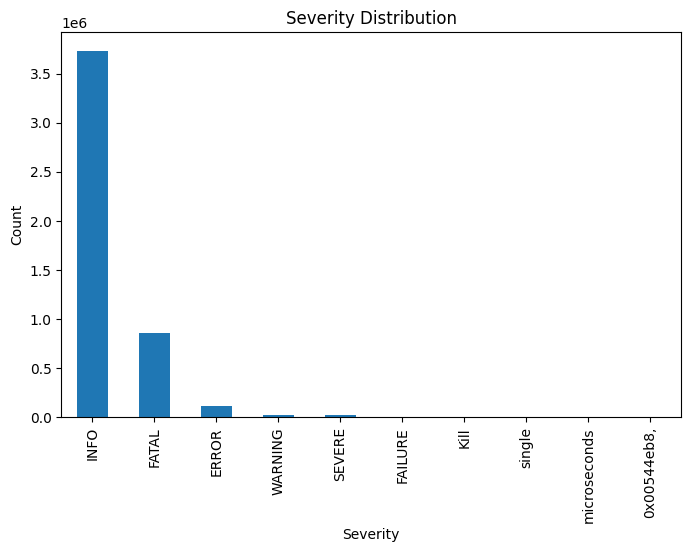

In [12]:
import matplotlib.pyplot as plt

severity_counts = df["Severity"].value_counts()

plt.figure(figsize=(8,5))
severity_counts.plot(kind="bar")

plt.title("Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Count")

plt.show()

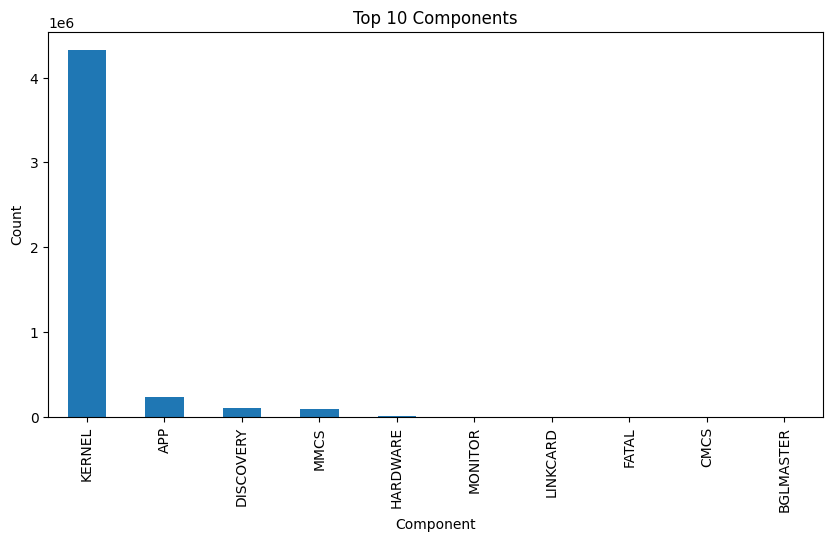

In [13]:
component_counts = df["Component"].value_counts().head(10)

plt.figure(figsize=(10,5))
component_counts.plot(kind="bar")

plt.title("Top 10 Components")
plt.xlabel("Component")
plt.ylabel("Count")

plt.show()

In [14]:
from collections import Counter
import re

text = " ".join(df["Message"].astype(str))

words = re.findall(r"\b[a-zA-Z]+\b", text.lower())

stop_words = {
    "the","is","of","and","to","in","for","at","on","a","an",
    "with","by","from","or","as","be","not","are","was","this",
    "that","it","can","no"
}

words = [w for w in words if w not in stop_words]

word_counts = Counter(words)

word_counts.most_common(30)

[('core', 1775907),
 ('generating', 1706751),
 ('iar', 634890),
 ('error', 632416),
 ('dear', 620452),
 ('alignment', 588055),
 ('exceptions', 586006),
 ('microseconds', 540384),
 ('interrupt', 481401),
 ('input', 445990),
 ('critical', 423075),
 ('interrupts', 416887),
 ('ciod', 350567),
 ('total', 314081),
 ('point', 310655),
 ('floating', 297273),
 ('double', 295764),
 ('hummer', 295764),
 ('data', 274012),
 ('time', 270260),
 ('spent', 270192),
 ('program', 255350),
 ('ddr', 221174),
 ('mask', 218766),
 ('corrected', 213437),
 ('instruction', 202310),
 ('ce', 201993),
 ('sym', 201206),
 ('file', 196010),
 ('signal', 174748)]

In [15]:
df["Node"].value_counts().head(20)

Node
R30-M0-N9-C:J16-U01    152329
NULL                    89296
R02-M1-N0-C:J12-U11     64651
R37-M1-NC-C:J02-U11     35288
UNKNOWN_LOCATION        27039
R16-M1-N2-C:J17-U01     16921
R26-M0-N0-I:J18-U11     14876
R02-M0-N4-C:J04-U11     14051
R06-M1-N6-C:J15-U01      4763
R55-M0-N9-C:J06-U11      4751
R26-M0-NB-C:J07-U01      4720
R30-M0-N7-C:J09-U01      4510
R23-M0-N8-C:J15-U11      4344
R03-M0-NB-C:J10-U11      4044
R63-M0-N3-C:J02-U11      3855
R35-M0-N0-C:J07-U01      3348
R01-M1-ND-C:J15-U11      2713
R10-M0-N7-C:J17-U01      2638
R00-M1-NF-C:J13-U11      1840
R63-M1-NC-C:J06-U01      1811
Name: count, dtype: int64

In [16]:
(
    df["Severity"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Severity
INFO            78.68
FATAL           18.01
ERROR            2.37
WARNING          0.49
SEVERE           0.40
FAILURE          0.04
Kill             0.01
single           0.00
microseconds     0.00
0x00544eb8,      0.00
Name: proportion, dtype: float64

In [17]:
(
    df["Component"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Component
KERNEL       91.08
APP           4.81
DISCOVERY     2.05
MMCS          1.87
HARDWARE      0.11
MONITOR       0.04
LINKCARD      0.02
FATAL         0.01
CMCS          0.00
BGLMASTER     0.00
a             0.00
0             0.00
SERV_NET      0.00
iar           0.00
Name: proportion, dtype: float64

In [18]:
import re

def clean_log(text):

    text = text.lower()

    # Hex değerleri kaldır
    text = re.sub(r'0x[a-fA-F0-9]+', ' ', text)

    # Dosya yollarını kaldır
    text = re.sub(r'/\S+', ' ', text)

    # Sayıları kaldır
    text = re.sub(r'\d+', ' ', text)

    # Noktalama işaretlerini kaldır
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Fazla boşlukları kaldır
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [19]:
df["Clean_Message"] = df["Message"].apply(clean_log)

In [20]:
df[["Message", "Clean_Message"]].head(20)

,Message,Clean_Message
0,instruction cache parity error corrected,instruction cache parity error corrected
1,instruction cache parity error corrected,instruction cache parity error corrected
2,instruction cache parity error corrected,instruction cache parity error corrected
3,instruction cache parity error corrected,instruction cache parity error corrected
4,instruction cache parity error corrected,instruction cache parity error corrected
5,instruction cache parity error corrected,instruction cache parity error corrected
6,instruction cache parity error corrected,instruction cache parity error corrected
7,instruction cache parity error corrected,instruction cache parity error corrected
8,instruction cache parity error corrected,instruction cache parity error corrected
9,instruction cache parity error corrected,instruction cache parity error corrected


In [21]:
examples = df[
    df["Message"].str.contains(
        "0x|/bgl|ASSERT|mask|ecid",
        case=False,
        na=False,
        regex=True
    )
][["Message", "Clean_Message"]]

examples.head(20)

,Message,Clean_Message
4882,3450051 L3 EDRAM error(s) (dcr 0x0157) detected and corrected,l edram error s dcr detected and corrected
4883,"CE sym 0, at 0x0b8580c0, mask 0x10",ce sym at mask
4885,16176627 L3 EDRAM error(s) (dcr 0x0157) detected and corrected,l edram error s dcr detected and corrected
4886,16176627 L3 EDRAM error(s) (dcr 0x0157) detected and corrected,l edram error s dcr detected and corrected
4904,207907 L3 EDRAM error(s) (dcr 0x0157) detected and corrected,l edram error s dcr detected and corrected
4908,"CE sym 25, at 0x04bfb9e0, mask 0x20",ce sym at mask
4910,"CE sym 25, at 0x04bfb9e0, mask 0x20",ce sym at mask
4912,"CE sym 25, at 0x04bfb9e0, mask 0x20",ce sym at mask
4914,"CE sym 25, at 0x04bfb9e0, mask 0x20",ce sym at mask
4916,"CE sym 25, at 0x04bfb9e0, mask 0x20",ce sym at mask


In [22]:
import re

def clean_log(text):

    text = text.lower()

    # Hex değerleri kaldır
    text = re.sub(r'0x[a-fA-F0-9]+', ' ', text)

    # Linux / Windows dosya yollarını kaldır
    text = re.sub(r'[/\\][^\s]+', ' ', text)

    # Sayıları kaldır
    text = re.sub(r'\d+', ' ', text)

    # error(s) -> error
    text = re.sub(r'\((.*?)\)', '', text)

    # Noktalama temizle
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Tek harfleri kaldır
    text = re.sub(r'\b[a-zA-Z]\b', ' ', text)

    # Fazla boşlukları temizle
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [23]:
df["Message_Length"] = df["Clean_Message"].str.len()
df["Word_Count"] = df["Clean_Message"].str.split().str.len()

df["Has_Number"] = df["Message"].str.contains(r"\d", regex=True)
df["Has_Hex"] = df["Message"].str.contains(r"0x", regex=False)
df["Has_Path"] = df["Message"].str.contains("/", regex=False)

keywords = [
    "error", "failed", "failure", "fatal", "interrupt",
    "timeout", "assert", "critical", "warning"
]

df["Keyword_Count"] = df["Clean_Message"].apply(
    lambda x: sum(word in x for word in keywords)
)

df["Unique_Word_Count"] = df["Clean_Message"].apply(
    lambda x: len(set(x.split()))
)

def uppercase_ratio(text):
    letters = [c for c in text if c.isalpha()]
    if len(letters) == 0:
        return 0
    return sum(c.isupper() for c in letters) / len(letters)

df["Uppercase_Ratio"] = df["Message"].apply(uppercase_ratio)

In [24]:
def assign_incident_type(message):
    msg = str(message).lower()

    if any(k in msg for k in ["ddr", "edram", "memory", "cache parity", "tlb"]):
        return "Memory Error"

    elif any(k in msg for k in ["assert", "exception", "signal", "core"]):
        return "Application Failure"

    elif any(k in msg for k in ["node card", "vpd", "assembly", "jtag", "pgood", "mpgood"]):
        return "Hardware Failure"

    elif any(k in msg for k in ["error loading", "program image", "exec format"]):
        return "Deployment Error"

    elif any(k in msg for k in ["interrupt", "machine check"]):
        return "System Interrupt"

    elif any(k in msg for k in ["link", "network", "packet", "transport"]):
        return "Network/Communication"

    elif any(k in msg for k in ["temperature", "volt", "rail", "clock"]):
        return "Power/Thermal Issue"

    else:
        return "Other"

In [25]:
df.to_parquet(
    "../dataset/BGL_Preprocessed.parquet",
    index=False
)

print("Preprocessed dataset saved successfully.")

Preprocessed dataset saved successfully.
